---
title: "Area Charts"
subtitle: "DS 2023 | Communicating with Data"
---

:::{image}images/area-charts.png
:width: 500px
:align: left
:::

## Overview

Area charts are essentially line graphs in which the area under the line is filled in with color. By coloring in the area, the focus shifts from trends to the **accumulation** or **composition** of the value represented by the x axis.

There are two main uses of area charts:

1. **Overlapping**: Area charts with multiple lines to make a comparison between groups (categorical features).

2. **Stacked**: Area charts that show how a whole is divided into component parts.


Like bar charts and unlike line graphs, area charts should always have zero baseline for the y axis.

In addtion, unlike bar charts, area charts tyoically do not show negative values.

## Use Cases

## A simple example

In this example, we look at energy consumption by fuel type from 1870 to 2021.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

energy = pd.read_csv("energy.csv").set_index('year')
energy

,Coal,Gas,Oil,"Cement, Flaring & Other Industry"
year,,,,
1870,529.404,NaN,3.133,NaN
1871,562.861,NaN,3.282,NaN
1872,622.674,NaN,3.698,NaN
1873,659.749,NaN,5.670,NaN
1874,616.754,NaN,6.243,NaN
...,...,...,...,...
2017,14506.974,7144.928,12242.628,2202.209
2018,14746.831,7529.847,12266.017,2283.813
2019,14725.978,7647.528,12345.653,2363.400


We alter the column names to simplify our visualization.

In [2]:
energy.columns = ['coal','gas','oil','other']

### Stacked 

In the chart below, the four lines and their areas are stacked on top of each other. 

The chart shows both the overall growth of energy consumption and the relative contribution of each fuel.

You can see, for example, that before around 1945, coal is the dominant source of energy. After that, oil consumption grows to rival it.

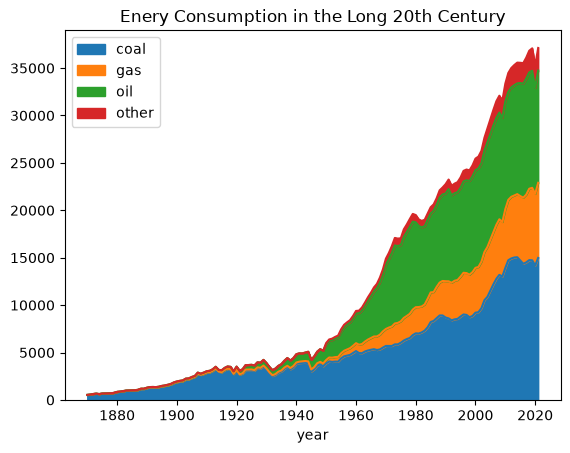

In [3]:
plot_title = "Enery Consumption in the Long 20th Century"
energy.plot.area(title=plot_title)
plt.show()

### Unstacked

If we set that stacked for `False`, what we see if the relative growth of each fuel type, but not the overall growth.

In this chart, we can see more clearly that although oil consumption grows rapidly after WWII, it still does not exceed the use of coal.

We can see, however, that from around the late 1960s to the turn of the century, gas use _did_ exceed coal use. 

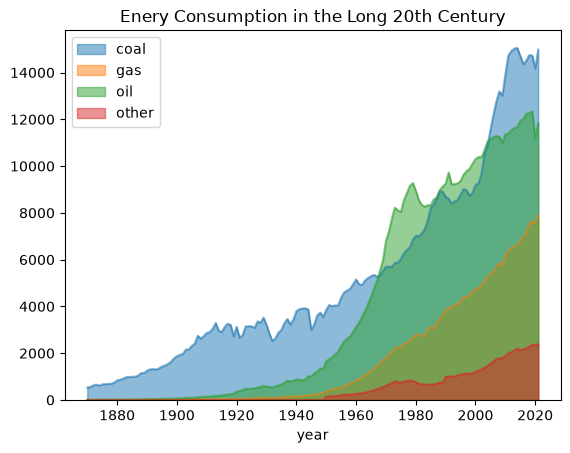

In [4]:
energy.plot.area(stacked=False, title=plot_title)
plt.show()

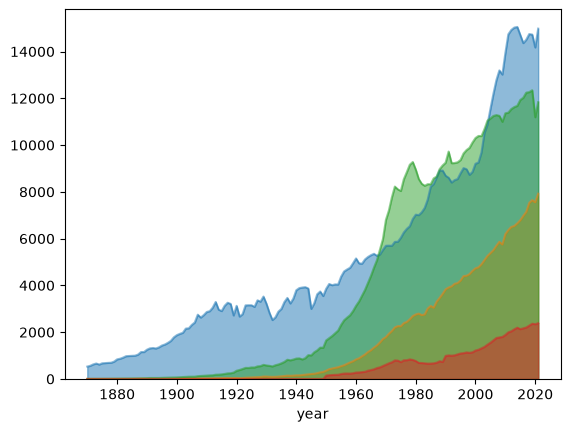

In [5]:
energy.plot.area(stacked=False, legend=False)
plt.show()

Note that the unstacked chart is similar to the basic line graph in not showing combined amounts.

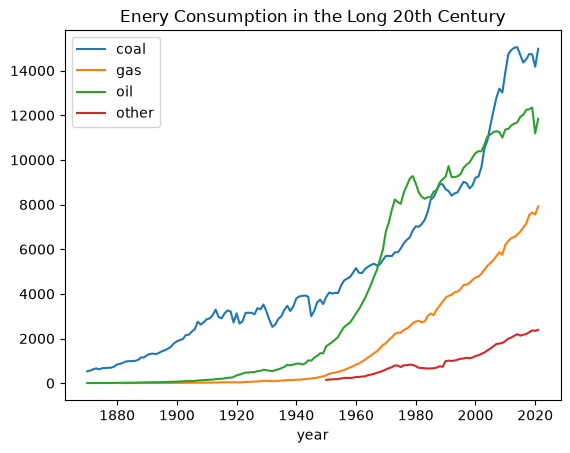

In [6]:
energy.plot(title=plot_title)
plt.show()

### Stacked with normed data

Now, if we want to show the relative amounts of fuel consumption over time without regard to absolute values, we can normalize the data so that the value of consumption for each year sums to $1$.

This shows rather dramatically how the use of other fuels grow relative to coal.

In [7]:
energy_norm = energy.div(energy.sum(axis=1), axis=0)
# energy_norm = energy.apply(lambda x: x / x.sum(), axis=1) # Another way to compute this
energy_norm

,coal,gas,oil,other
year,,,,
1870,0.994117,NaN,0.005883,NaN
1871,0.994203,NaN,0.005797,NaN
1872,0.994096,NaN,0.005904,NaN
1873,0.991479,NaN,0.008521,NaN
1874,0.989979,NaN,0.010021,NaN
...,...,...,...,...
2017,0.401892,0.197938,0.339162,0.061009
2018,0.400441,0.204468,0.333076,0.062015
2019,0.397113,0.206230,0.332923,0.063733


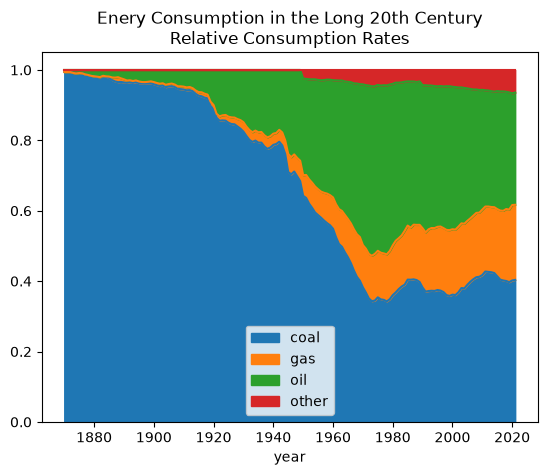

In [8]:
energy_norm.plot.area(title=plot_title + "\nRelative Consumption Rates")
plt.show()

### Unstacked with normed data

We can also show the normed data without stacking.

Again we see that coal consumption declines as oil increases.

We can also see clearly the period in which oil exceeds coal.

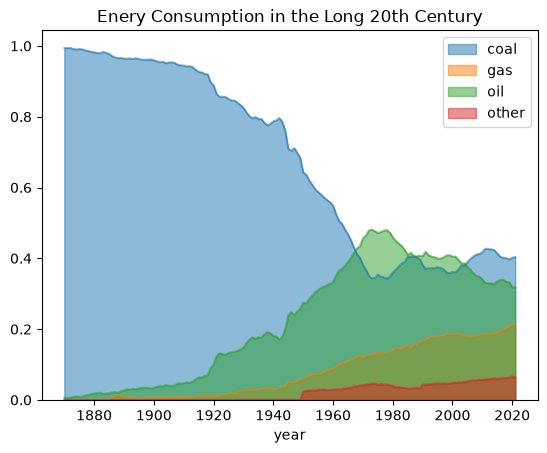

In [9]:
energy_norm.plot.area(stacked=False, title=plot_title)
plt.show()

## Drilling Down on Coal and Oil

Let's look more closely at the relationship between coal and oil after WWII.

A simple line graph shows the growth and competetion between the two.

Note, again, the truncation of the y axis in a line graph. It zooms in on the trend itself, not the magnitude.

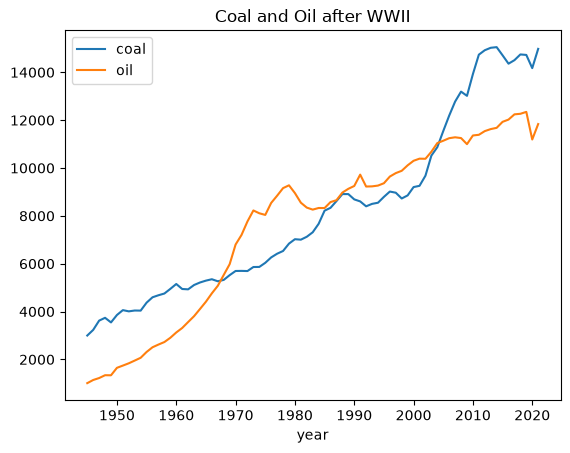

In [10]:
coal_and_oil = energy.query("year >= 1945")[['coal','oil']]

plot_title2 = "Coal and Oil after WWII"
coal_and_oil.plot(title=plot_title2)
plt.show()

A stacked area chart shows 

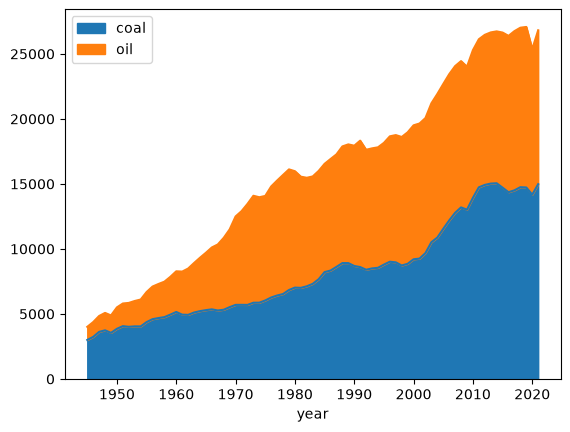

In [11]:
coal_and_oil.plot.area()
plt.show()

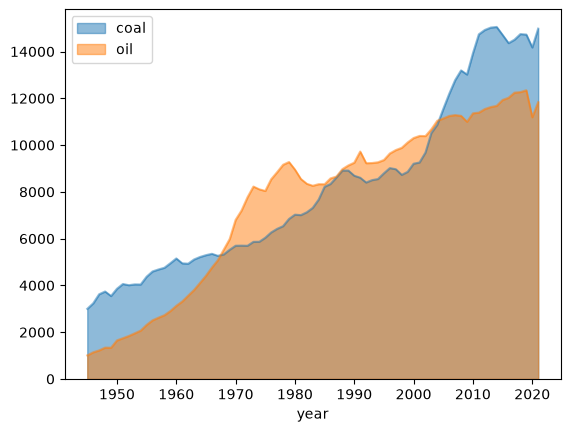

In [12]:
coal_and_oil.plot.area(stacked=False)
plt.show()

In [13]:
coal_and_oil_norm = energy_norm.query("year >= 1945")[['coal','oil']]

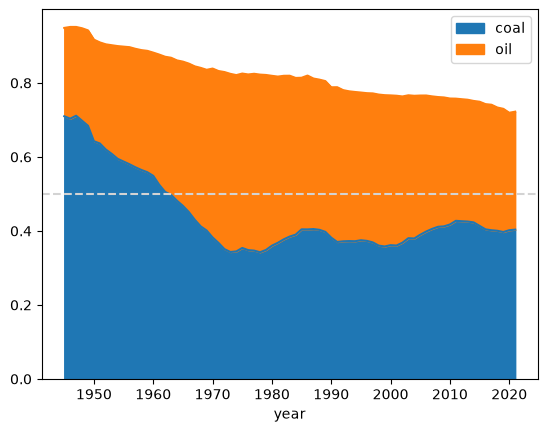

In [14]:
ax = coal_and_oil_norm.plot.area()
ax.axhline(.5, ls='--', c='lightgray')
plt.show()

Note how the above is an improvement on using a bar chart for this.

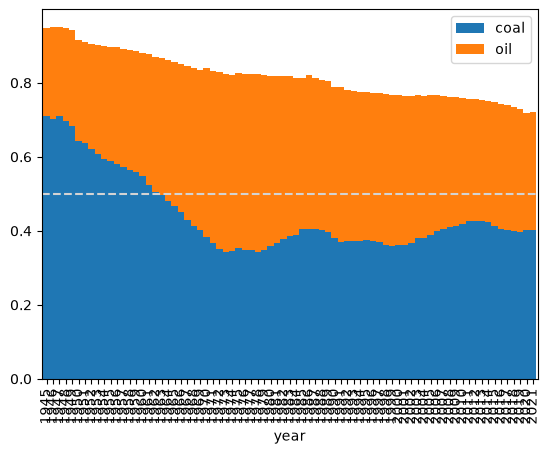

In [15]:
ax = coal_and_oil_norm.plot.bar(stacked=True, width=1)
ax.axhline(.5, ls='--', c='lightgray')
plt.show()

Finally, an unstacked view of the normed data shows clearly the competition between the two fuel sources.

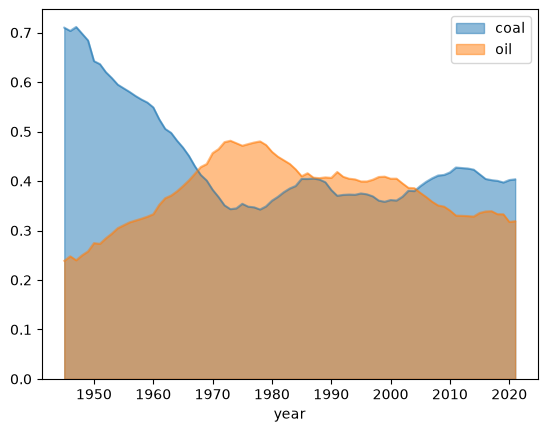

In [16]:
coal_and_oil_norm.plot.area(stacked=False)
plt.show()

## Bonus: Difference Charts

```{figure}https://upload.wikimedia.org/wikipedia/commons/thumb/5/52/Playfair_TimeSeries-2.png/1280px-Playfair_TimeSeries-2.png

Playfair's trade-balance time-series chart, published in Commercial and Political Atlas, 1786.
From [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Playfair_TimeSeries-2.png)
```

/var/folders/fb/hhf80dqn5x190kxk7_y8557r0000gq/T/ipykernel_21214/2895272154.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of min will be keyword-only.
  coal_and_oil.min(1).plot.area(color='white', ax=ax)


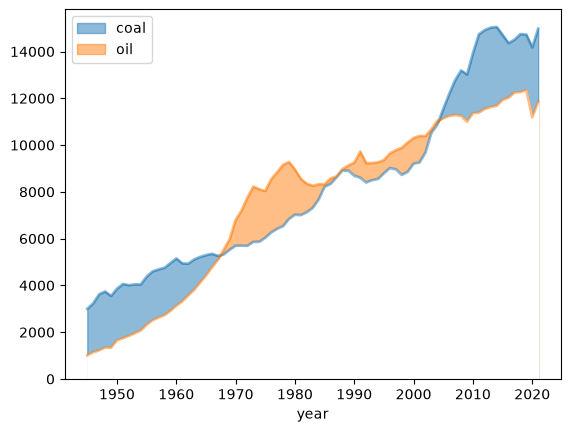

In [20]:
ax = coal_and_oil.plot.area(stacked=False)

# Create a new series based on the minimumn value of coal vs oil
# and plot its area
coal_and_oil.min(1).plot.area(color='white', ax=ax)

lines = ax.get_lines()

# Coal line
lines[0].set_color('tab:blue')
lines[0].set_linewidth(2)

# Oil line
lines[1].set_color('tab:orange')
lines[1].set_linewidth(2)

# Mask line (hidden)
lines[2].set_linewidth(0)

plt.show()

If we want to avoid the gray lines on the right and left, we can use Matplotlib's `ax.fill_between()` method.

To use this method, we create a pure Matplotlib plot.

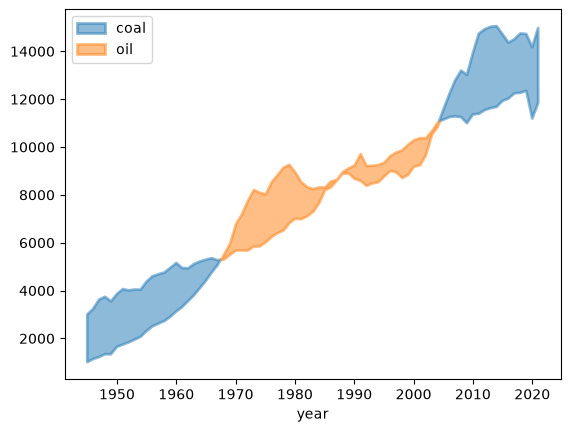

In [21]:
# Instantiate our figure and axes objects
fig, ax = plt.subplots()

# Get our data to map 
years = coal_and_oil.index
coal = coal_and_oil['coal']
oil = coal_and_oil['oil']

# Plot 1: Fill the gap when coal exceeds oil
ax.fill_between(years, oil, coal, where = coal >= oil, interpolate=True,
                color='tab:blue', alpha=0.5, lw=2, label='coal')

# Plot 2: Fill the gap when oil exceeds coal
ax.fill_between(years, coal, oil, where = oil > coal, interpolate=True,
                color='tab:orange', alpha=0.5, lw=2, label='oil')

ax.set_xlabel('year')
ax.legend()
plt.show()

## Caveats

Although each of these charts gives insight to energy consumption over time, it is important to convey to the reader just what they are looking at.

In the first diagram, where the curves are stacked, a naive reader may not be aware of this, and think that all fuel usage is rising. In fact, might think that coal has the least usage since it is on the bottom.

Even if readers known that the plots are stacked, their eyes may deceive them into thinking that all of the fuel usages are always rising. But we know that coal usage actually declines for something like a $40$ year period.

Another possible source of confusion occurs when an area chart of normalized data is presented. Consider how the relative proportion of coal usage decreases even though the absolute usage increases (see image below).

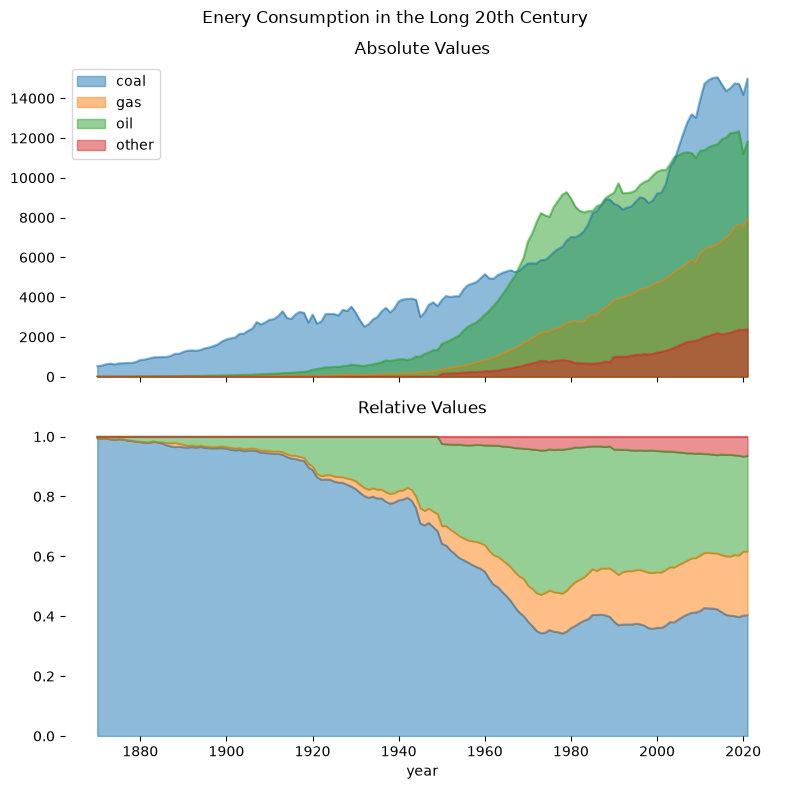

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
energy.plot.area(stacked=False, ax=ax[0], title="Absolute Values")
energy_norm.plot.area(stacked=True, ax=ax[1], legend=False, title="Relative Values", alpha=.5)
plt.suptitle(plot_title)
sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()